In [ ]:
import numpy as np
import netCDF4
import glob
import time

from scipy.io import loadmat, savemat
from matplotlib import pyplot as plt
from google.colab import drive
drive.mount("/content/drive",  force_remount=True)

wdir = '/content/drive/My Drive/SRGANs/'
data_folder = '/content/drive/My Drive/AI_CPRCM/Data/'


import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, metrics, losses
from tensorflow.keras.callbacks import ModelCheckpoint

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

Mounted at /content/drive


In [ ]:

# 3km:  tas, pr 
# 12km: ta500,  ta700,  ta850,  ta950, 
#	hus500, hus700, hus850, hus950, 
#	ua500,  ua700,  ua850,  ua950, 
#	va500,  va700,  va850,  va950, 
#	phi500, phi700, phi850, phi950,
# var = 'ta500' 
# exp_name = '12km' # '3km', '12km'

""" 
inputs: phi500, phi700, phi850, phi950, hus500, hus700, hus850, hus950,  ta500, ta700, ta850, ta950, ua500, ua700, ua850, ua950, va500, va700, va850, va950
outputs: pr 
"""

dir_lr = data_folder + 'Coarse_Resolution_12km/6-hour/' 
dir_hr = data_folder + 'High_Resolution_3km/6-hour/'


lr_files = glob.glob(dir_lr + '*')
lr_files.sort()
print(lr_files)
lr_files = lr_files[16:17]
# lr_files.pop(12)


hr_files = glob.glob(dir_hr + '*')
hr_files.sort()
print(hr_files)
# hr_files.pop(1)
hr_files = hr_files[0:1]




['/content/drive/My Drive/AI_CPRCM/Data/Coarse_Resolution_12km/6-hour/hus500_12km_6hr_200001010000-200912311800.nc', '/content/drive/My Drive/AI_CPRCM/Data/Coarse_Resolution_12km/6-hour/hus500_12km_6hr_July_200001010000-200912311800.nc', '/content/drive/My Drive/AI_CPRCM/Data/Coarse_Resolution_12km/6-hour/hus700_12km_6hr_200001010000-200912311800.nc', '/content/drive/My Drive/AI_CPRCM/Data/Coarse_Resolution_12km/6-hour/hus700_12km_6hr_July_200001010000-200912311800.nc', '/content/drive/My Drive/AI_CPRCM/Data/Coarse_Resolution_12km/6-hour/hus850_12km_6hr_200001010000-200912311800.nc', '/content/drive/My Drive/AI_CPRCM/Data/Coarse_Resolution_12km/6-hour/hus850_12km_6hr_July_200001010000-200912311800.nc', '/content/drive/My Drive/AI_CPRCM/Data/Coarse_Resolution_12km/6-hour/hus950_12km_6hr_200001010000-200912311800.nc', '/content/drive/My Drive/AI_CPRCM/Data/Coarse_Resolution_12km/6-hour/hus950_12km_6hr_July_200001010000-200912311800.nc', '/content/drive/My Drive/AI_CPRCM/Data/Coarse_Resol

In [ ]:
nc12 = []
var_list12 = []
for file in lr_files:
  data = netCDF4.Dataset(file)
  var = list(data.variables.keys())[-1]
  nc12.append(data.variables[var])
  var_list12.append(var)

nc3 = []
var_list3 = []
for file in hr_files:
  data = netCDF4.Dataset(file)
  var = list(data.variables.keys())[-1]
  nc3.append(data.variables[var])
  var_list3.append(var)

print(var_list12)
print(var_list3)

['pr']
['pr']


In [ ]:
nc12 = np.array(nc12)
nc3 = np.array(nc3)



In [ ]:
def scale(scaler, var):
  shape = var.shape
  var = var.reshape((shape[0], -1))
  var = scaler.fit_transform(var)
  var = var.reshape(shape)
  return scaler, var

scalers_list12 = []
for i in range(len(nc12)):
  var = nc12[i]
  scaler = MinMaxScaler()
  scaler, var = scale(scaler, var)
  scalers_list12.append(scaler)
  nc12[i] = var

scalers_list3 = []
for i in range(len(nc3)):
  var = nc3[i]
  scaler = MinMaxScaler()
  scaler, var = scale(scaler, var)
  scalers_list3.append(scaler)
  nc3[i] = var

nc12 = nc12.transpose((1, 2, 3, 0))[:-12]
nc3 = nc3.transpose((1, 2, 3, 0))[:-12]
nc3 = nc3[:, :, 1:-1]

print(nc12.shape)
print(nc3.shape)

(14600, 22, 26, 1)
(14600, 88, 104, 1)


In [ ]:
max_pool_2d = layers.MaxPooling2D(pool_size=4, padding='valid')
nc12_gen = max_pool_2d(nc3)
nc12_gen = nc12_gen.numpy()
print(nc12_gen.shape)

(14600, 22, 26, 1)


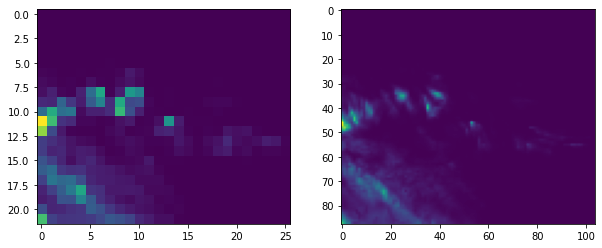

In [ ]:
n = 2000

var12 = nc12_gen[n, :, :, 0]
var3 = nc3[n, :, :, 0]

fig, ax = plt.subplots(1, 2, figsize = (10, 4))

ax[0].imshow(var12)
ax[1].imshow(var3)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(nc12_gen, nc3, test_size = 3000, random_state = 24)

dataset_train = tf.data.Dataset.from_tensor_slices((X_train, y_train))
dataset_valid = tf.data.Dataset.from_tensor_slices((X_test, y_test))



In [ ]:

def model_generator(nx, nz, channels, subsampling, n_res_block, batch_size):

    inputs = layers.Input(shape=(int(nz / subsampling), int(nx / subsampling), channels), batch_size=batch_size, name='low-res-input')

    conv_1 = layers.Conv2D(filters=64, kernel_size=5, strides=1, activation='linear', padding='same')(inputs)

    prelu_1 = layers.PReLU()(conv_1) #layers.PReLU(alpha_initializer='zeros', alpha_regularizer=None, alpha_constraint=None, shared_axes=[2,3])(conv_1)

    res_block = prelu_1

    for index in range(n_res_block):

        res_block = res_block_gen(res_block, 3, 64, 1)


    conv_2 = layers.Conv2D(filters = 64, kernel_size = 3, strides = 1, padding = "same")(res_block)
    batch_1 = layers.BatchNormalization(momentum = 0.5)(conv_2) #axis=1, 
    add_1 = layers.Add()([prelu_1, batch_1])

    up_sampling = add_1

    for index in range(int(np.log2(subsampling))):

        up_sampling = up_sampling_block(up_sampling, 3, 256, 1)

    conv_3 = layers.Conv2D(filters = 1, kernel_size = 3, strides = 1, padding = "same")(up_sampling)
    outputs = conv_3


    model = models.Model(inputs, outputs, name='Generator')


    print(model.summary())

    return model


def res_block_gen(model, kernal_size, filters, strides):

    gen = model
    
    model = layers.Conv2D(filters = filters, kernel_size = kernal_size, strides = strides, padding = "same")(model)
    model = layers.BatchNormalization(momentum = 0.5)(model)
    # Using Parametric ReLU
    model = layers.PReLU()(model) #layers.PReLU(alpha_initializer='zeros', alpha_regularizer=None, alpha_constraint=None, shared_axes=[2,3])(model)
    model = layers.Conv2D(filters = filters, kernel_size = kernal_size, strides = strides, padding = "same")(model)
    model = layers.BatchNormalization(momentum = 0.5)(model)
        
    model = layers.Add()([gen, model])
    
    return model


def up_sampling_block(model, kernal_size, filters, strides):

    # In place of Conv2D and UpSampling2D we can also use Conv2DTranspose (Both are used for Deconvolution)
    # Even we can have our own function for deconvolution (i.e one made in Utils.py)
    #model = Conv2DTranspose(filters = filters, kernel_size = kernal_size, strides = strides, padding = "same")(model)
    model = layers.Conv2D(filters = filters, kernel_size = kernal_size, strides = strides, padding = "same")(model)
    model = layers.UpSampling2D(size = 2)(model)
    # model = SubpixelConv2D(model.shape, scale=2)(model)
    model = layers.LeakyReLU(alpha = 0.2)(model)
    
    return model


def SubpixelConv2D(input_shape, scale=4):
    
    def subpixel_shape(input_shape):
        dims = [input_shape[0],
                int(input_shape[1] / (scale ** 2)),
                input_shape[2] * scale,
                input_shape[3] * scale]
        output_shape = tuple(dims)
        return output_shape

    def subpixel(x):
        return tf.nn.depth_to_space(x, scale, data_format='NCHW')


    return layers.Lambda(subpixel, output_shape=subpixel_shape)

In [ ]:
def model_discriminator(nx, nz, channels, batch_size):

    inputs = layers.Input(shape=(nz, nx, channels), batch_size=batch_size, name='high-res-input')
        
    model = layers.Conv2D(filters = 16, kernel_size = 5, strides = 1, padding = "same")(inputs)
    model = layers.LeakyReLU(alpha = 0.2)(model)
    
    model = discriminator_block(model, 16, 3, 2)
    model = discriminator_block(model, 32, 3, 1)
    model = discriminator_block(model, 32, 3, 2)
    model = discriminator_block(model, 64, 3, 1)
    model = discriminator_block(model, 64, 3, 2)
    model = discriminator_block(model, 128, 3, 1)
    model = discriminator_block(model, 128, 3, 2)
    
    model = layers.Flatten()(model)
    model = layers.Dense(1024)(model)
    model = layers.LeakyReLU(alpha = 0.2)(model)

    model = layers.Dense(1)(model)
    model = layers.Activation('sigmoid')(model) 
    
    model = models.Model(inputs=inputs, outputs = model, name='Discriminator')


    print(model.summary())
    
    return model


def discriminator_block(model, filters, kernel_size, strides):
        
    model = layers.Conv2D(filters = filters, kernel_size = kernel_size, strides = strides, padding = "same")(model)
    model = layers.BatchNormalization(momentum = 0.5)(model)
    model = layers.LeakyReLU(alpha = 0.2)(model)
    
    return model

In [ ]:
class SRGAN(models.Model):
    def __init__(self, generator, discriminator, **kwargs):
        super(SRGAN, self).__init__(**kwargs)
        self.generator = generator
        self.discriminator = discriminator
        self.loss_tracker_1 = metrics.Mean(name="gen_loss")
        self.loss_tracker_2 = metrics.Mean(name="disc_loss")
        

    def compile(self, generator_optimizer, discriminator_optimizer, generator_loss, discriminator_loss):
        super(SRGAN, self).compile()
        self.gen_optimizer = generator_optimizer
        self.disc_optimizer = discriminator_optimizer
        self.gen_loss = generator_loss
        self.disc_loss = discriminator_loss

    @tf.function
    def train_step(self, data):
        lr_predic = data[0]
        hr_predic = data[1]

        with tf.GradientTape(persistent = True) as tape:

            generated_batch = self.generator(lr_predic, training=True)
            
            real_ptv = self.discriminator(hr_predic, training=True)
            fake_ptv = self.discriminator(generated_batch, training=True)
            gen_loss = self.gen_loss(fake_ptv, generated_batch, hr_predic)
            disc_loss = self.disc_loss(real_ptv, fake_ptv)

        gradients_of_generator = tape.gradient(gen_loss, self.generator.trainable_variables)
        gradients_of_discriminator = tape.gradient(disc_loss, self.discriminator.trainable_variables)
        
        self.gen_optimizer.apply_gradients(zip(gradients_of_generator, self.generator.trainable_variables))
        self.disc_optimizer.apply_gradients(zip(gradients_of_discriminator, self.discriminator.trainable_variables))
        
        self.loss_tracker_1.update_state(gen_loss)
        self.loss_tracker_2.update_state(disc_loss)
        return {"gen_loss": self.loss_tracker_1.result(), "disc_loss": self.loss_tracker_2.result()}

    @tf.function
    def test_step(self, data):
        lr_predic = data[0]
        hr_predic = data[1]
        generated_batch = self.generator(lr_predic, training=False)

        real_ptv = self.discriminator(hr_predic, training=False)
        fake_ptv = self.discriminator(generated_batch, training=False)

        gen_loss = self.gen_loss(fake_ptv, generated_batch, hr_predic)
        disc_loss = self.disc_loss(real_ptv, fake_ptv)
          
        self.loss_tracker_1.update_state(gen_loss)
        self.loss_tracker_2.update_state(disc_loss)
        return {"gen_loss": self.loss_tracker_1.result(), "disc_loss": self.loss_tracker_2.result()}

    @property
    def metrics(self):
        return [self.loss_tracker_1, self.loss_tracker_2]
    

In [ ]:
def discriminator_loss(real_Y, fake_Y):
    cross_entropy = losses.BinaryCrossentropy()
    real_loss = cross_entropy(tf.ones(real_Y.shape) - tf.random.uniform(real_Y.shape)*0.2, real_Y)
    fake_loss = cross_entropy(tf.random.uniform(fake_Y.shape)*0.2, fake_Y)
    total_loss = 0.5 * (real_loss + fake_loss)
    return total_loss


def generator_loss(fake_Y, hr_predic, hr_target):

    cross_entropy = losses.BinaryCrossentropy()
    
    adversarial_loss = cross_entropy(
      tf.ones(fake_Y.shape) - tf.random.uniform(fake_Y.shape) * 0.2, 
      fake_Y
    )
    content_loss = losses.MSE(hr_target, hr_predic)
    return content_loss + 1e-6*adversarial_loss 

In [ ]:
batch_size = 50
dataset_train = dataset_train.batch(batch_size)
dataset_valid = dataset_valid.batch(batch_size)

In [ ]:
"""
    Training
"""

model_name = f"model_1"

generator_optimizer = optimizers.Adam(1e-4)
discriminator_optimizer = optimizers.Adam(1e-4)

subsampling_lr = 4
n_res_block = 8
input_channels = 1
output_channels = 1

nx = 104
nz = 88

generator =  model_generator(nx, nz, input_channels, subsampling_lr, n_res_block, batch_size)
discriminator = model_discriminator(nx, nz, output_channels, batch_size)



Model: "Discriminator"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 high-res-input (InputLayer)  [(50, 88, 104, 1)]       0         
                                                                 
 conv2d_21 (Conv2D)          (50, 88, 104, 16)         416       
                                                                 
 leaky_re_lu_2 (LeakyReLU)   (50, 88, 104, 16)         0         
                                                                 
 conv2d_22 (Conv2D)          (50, 44, 52, 16)          2320      
                                                                 
 batch_normalization_17 (Bat  (50, 44, 52, 16)         64        
 chNormalization)                                                
                                                                 
 leaky_re_lu_3 (LeakyReLU)   (50, 44, 52, 16)          0         
                                                     

In [ ]:
model = SRGAN(generator, discriminator)
model.compile(generator_optimizer, discriminator_optimizer, generator_loss, discriminator_loss)

checkpoint_filepath = wdir + 'checkpoint_NN'
checkpoint = ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=True,
    monitor='val_gen_loss',
    mode='min',
    save_best_only=True)

callbacks_list = [checkpoint]

hist = model.fit(dataset_train, epochs = 100, callbacks = callbacks_list, validation_data = dataset_valid, verbose = 1)
savemat(wdir + f'loss_{model_name}.mat', hist.history)
model.load_weights(checkpoint_filepath)

generator.save(wdir + f'{model_name}_generator.h5')
discriminator.save(wdir + f'{model_name}_discriminator.h5')

Epoch 1/100
232/232 [==============================] - 150s 493ms/step - gen_loss: 0.0107 - disc_loss: 0.3599 - val_gen_loss: 0.0021 - val_disc_loss: 0.7051
Epoch 2/100
232/232 [==============================] - 114s 491ms/step - gen_loss: 0.0015 - disc_loss: 0.3408 - val_gen_loss: 9.5525e-04 - val_disc_loss: 0.8831
Epoch 3/100
232/232 [==============================] - 114s 491ms/step - gen_loss: 0.0010 - disc_loss: 0.3366 - val_gen_loss: 7.1325e-04 - val_disc_loss: 0.6523
Epoch 4/100
232/232 [==============================] - 114s 491ms/step - gen_loss: 8.8447e-04 - disc_loss: 0.3344 - val_gen_loss: 6.8754e-04 - val_disc_loss: 0.7756
Epoch 5/100
232/232 [==============================] - 113s 489ms/step - gen_loss: 8.0087e-04 - disc_loss: 0.3315 - val_gen_loss: 8.5519e-04 - val_disc_loss: 0.8035
Epoch 6/100
232/232 [==============================] - 114s 491ms/step - gen_loss: 7.2139e-04 - disc_loss: 0.3317 - val_gen_loss: 5.7839e-04 - val_disc_loss: 0.7825
Epoch 7/100
232/232 [=====

/usr/local/lib/python3.7/dist-packages/keras/engine/functional.py:1410: CustomMaskWarning: Custom mask layers require a config and must override get_config. When loading, the custom mask layer must be passed to the custom_objects argument.
  layer_config = serialize_layer_fn(layer)


In [ ]:
pr_pred = generator.predict(X_test)

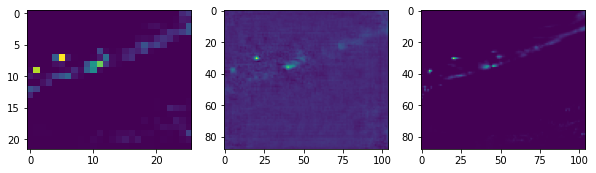

In [ ]:
n = 50

var_p = pr_pred[n, :,:, 0]
var_ref = y_test[n, :,:, 0]
var_in = X_test[n, :,:, 0]

fig, ax = plt.subplots(1, 3, figsize = (10, 4))

ax[0].imshow(var_in)
ax[1].imshow(var_p)
ax[2].imshow(var_ref)

In [ ]:
np.savez_compressed(wdir + 'preds', hr = y_test, hr_p = pr_pred)